# CNN propia (baseline)

Brain Tumor Probability (Binary Classification)
- Yes: tumor presente
- No: tumor ausente

In [5]:
# pip install scikit-learn
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from pathlib import Path

## Hyperparameters (Model Configuration)

| Parameter | Value / Configuration | Rationale / Reference |
| --- | --- | --- |
| **Input Dimensions** | 256 | 256 x 256 pixels square resolution for spatial consistency. |
| **Batch Size** | 8 | Set in accordance with Angelina et al. (2026, p. 9) for memory constraints. |
| **Epochs** | 100 | Sufficient horizon to ensure convergence. |
| **Learning Rate** | 0.0001 (Static) | Set in accordance with He et al. (2015, p. 4). |
| **Dropout Rate** | 0.5 | Applied for regularization to mitigate overfitting (Hinton et al., 2012, p. 2). |
| **Activation Function** | Sigmoid | Employed in the final layer for single-class probability mapping. |
| **Loss Function** | Binary Cross-Entropy | Selected to complement the single-neuron sigmoid output. |
| **Optimizer** | Adam | Back propagation optimization. |
| **Data Augmentation** | Rotation, translation, zoom, and contrast | Applied only to training batches to reduce overfitting in the small dataset. |

- He, K., Zhang, X., Ren, S., y Sun, J. (2015). Deep residual learning for image recognition. arXiv. https://doi.org/10.48550/arXiv.1512.03385
- Hinton, G. E., Srivastava, N., Krizhevsky, A., Sutskever, I., y Salakhutdinov, R. R. (2012). Improving neural networks by preventing co-adaptation of feature detectors. arXiv. https://doi.org/10.48550/arXiv.1207.0580
- Angelina, C. L., Xiao, F.-R., Vyas, S., Yang, P.-C., Chang, H.-T., & Luo, Y. (2026). Mod-SE(2): A geometric deep learning framework for brain tumor classification and segmentation in MRI images. Journal of Biomedical Science, 33, Article 11. https://doi.org/10.1186/s12929-025-01213-y

In [3]:
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT = 0.5
LOSS_METHOD = "binary_crossentropy"
ACTIVATION = "sigmoid"
LABEL_MODE = "binary"
SEED = 42

TRAIN_DIR = "data/dataset_ready/train"
VAL_DIR = "data/dataset_ready/val"
TEST_DIR = "data/dataset_ready/test"

MODEL_TAG = "cnn_propia_02"

## Dataset Structure
```text
data/dataset_ready/
+-- train/
|   +-- no/
|   +-- yes/
+-- val/
|   +-- no/
|   +-- yes/
+-- test/
    +-- no/
    +-- yes/
```

En TensorFlow/Keras, la asignacion de etiquetas para conjuntos de datos estructurados en carpetas locales no requiere un etiquetado manual en codigo. `image_dataset_from_directory()` infiere las clases por el nombre de las carpetas y las ordena alfabeticamente: `no -> 0`, `yes -> 1`.

El conjunto de **validation** se usa correctamente cuando se pasa como `validation_data=val_ds` en `model.fit()`: sirve para monitorear el entrenamiento, seleccionar el mejor checkpoint y activar early stopping. No debe recibir data augmentation ni debe usarse para reportar el resultado final. El conjunto de **test** se mantiene separado hasta el final para medir el desempeno del modelo ya entrenado.

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=False
)

classes = train_ds.class_names # Binary: ['no', 'yes']
num_classes = len(classes)
print(classes)

Found 151 files belonging to 2 classes.


Found 51 files belonging to 2 classes.
['no', 'yes']


## Data Augmentation

Se agrega data augmentation para generar variaciones realistas de las imagenes de entrenamiento sin crear archivos nuevos en disco. En cada epoca, Keras aplica pequenas rotaciones, traslaciones, zoom y cambios de contraste a los batches de `train_ds`.

Esto busca que el modelo no memorice tan facil el dataset pequeno y aprenda patrones mas robustos. La validacion y el test se dejan sin augmentation para medir el desempeno sobre imagenes reales, no transformadas artificialmente.

For the classification head, the two 4096-unit dense layers were removed, as the task involved only two output classes (N=256), making such a high-capacity head unnecessarily complex.
| Block       | Architecture                                |
|-------------|---------------------------------------------|
| **VGG16 Layer 1** | Conv(64) → Conv(64) → MaxPool               |
| **VGG16 Layer 2** | Conv(128) → Conv(128) → MaxPool             |
| **VGG16 Layer 3**| Conv(256) → Conv(256) → Conv(256) → MaxPool |
| **VGG16 Layer 4** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **VGG16 Layer 5** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **Head (manual)** | Flatten → Dense(1000) → Softmax |
- He, K., Zhang, X., Ren, S., y Sun, J. (2015). Deep residual learning for image recognition. arXiv. https://doi.org/10.48550/arXiv.1512.03385, page 4

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, MaxPooling2D, Conv2D
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom, RandomContrast

# Data augmentation dentro del modelo: se activa en training y se desactiva en validation/test.
data_augmentation = Sequential(
    [
        RandomRotation(0.05, fill_mode="nearest"),
        RandomTranslation(0.05, 0.05, fill_mode="nearest"),
        RandomZoom(0.10, fill_mode="nearest"),
        RandomContrast(0.10),
    ],
    name="data_augmentation"
)

# Modelo inspirado de VGG16 https://doi.org/10.48550/arXiv.1512.03385
model = Sequential()
model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(data_augmentation)

# Block 1
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Head
model.add(Flatten())
model.add(Dense(32, activation="relu"))
model.add(Dropout(DROPOUT))

# Output
model.add(Dense(1, activation=ACTIVATION)) # Binary = 1

# N=256, a pesar de data augmentation, pienso que sería mejor alrededor de 500k parámetros para evitar overfitting

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,401 (2.05 MB)

 Trainable params: 536,401 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [8]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=LOSS_METHOD,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

## Train

Ejemplo de overfitting: 

Epoch 1
train acc = 0.80,
val acc   = 0.78

Epoch 5
train acc = 0.95,
val acc   = 0.90

Epoch 10
train acc = 0.99,
val acc   = 0.75

In [9]:
# 5 Minutes
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        f"checkpoints/{MODEL_TAG}/best_{MODEL_TAG}.keras",
        save_best_only=True,
        monitor="val_accuracy"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - accuracy: 0.5695 - auc: 0.5259 - loss: 2.6025 - precision: 0.6273 - recall: 0.7419 - val_accuracy: 0.6078 - val_auc: 0.6363 - val_loss: 0.6491 - val_precision: 0.6078 - val_recall: 1.0000
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.6093 - auc: 0.5604 - loss: 0.6536 - precision: 0.6214 - recall: 0.9355 - val_accuracy: 0.6078 - val_auc: 0.6210 - val_loss: 0.6684 - val_precision: 0.6122 - val_recall: 0.9677
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.6093 - auc: 0.5510 - loss: 0.6691 - precision: 0.6197 - recall: 0.9462 - val_accuracy: 0.5882 - val_auc: 0.5379 - val_loss: 0.6685 - val_precision: 0.6042 - val_recall: 0.9355
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.5960 - auc: 0.5838 - loss: 0.6441 - precision: 0.6311 - recall: 0.8280 - val_accuracy: 0.5882 - val_auc: 0.5976 - val_loss: 0.6944 - val_precision: 0.6316 - val_recall: 0.7742
Epoch 5/100
19/19 ━━━━━━━━━━

## Training Curves

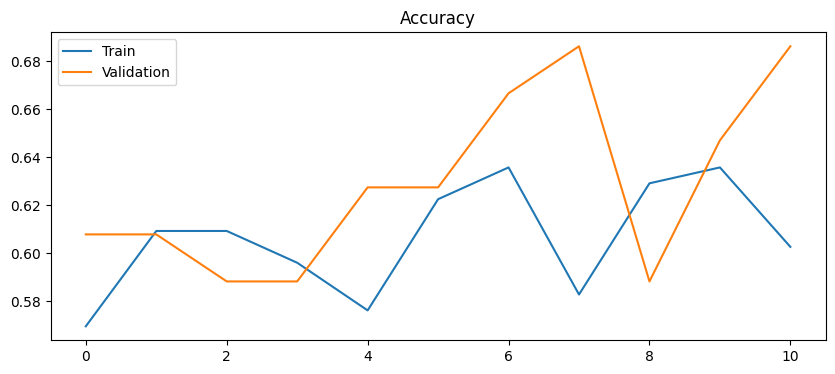

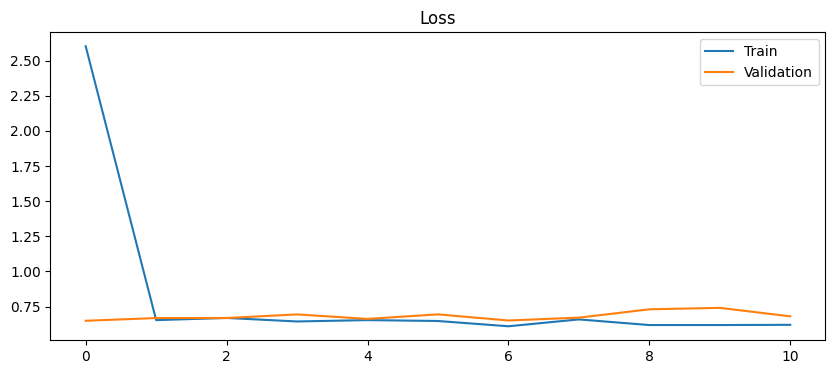

In [10]:
reportPath = os.path.join("reports", MODEL_TAG)
Path(reportPath).mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.savefig(os.path.join(reportPath, "accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.savefig(os.path.join(reportPath, "loss.png"), dpi=300, bbox_inches="tight")
plt.show()

## Save Model

In [11]:
save_path = Path(f"models/{MODEL_TAG}.keras")
save_path.parent.mkdir(parents=True, exist_ok=True)
model.save(save_path)
print("Model saved.")

Model saved.
